In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
from pathlib import Path
import warnings
import scienceplots
warnings.filterwarnings('ignore', category=FutureWarning)

plt.style.use(['science', 'ieee', 'no-latex'])
sns.set_style("whitegrid", {'grid.alpha': 0.25, 'grid.linewidth': 0.4})

COL_W = 3.5
PAGE_W = 7.2
GOLDEN = 1.618

FIGURES_DIR = Path('/data/jane/convert/math_gender/conversion_test/2_analysis/figures')
FIGURES_DIR.mkdir(exist_ok=True)

mpl.rcParams.update({
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.05,
    'font.size': 9,
    'axes.titlesize': 10,
    'axes.labelsize': 9,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 8,
    'legend.title_fontsize': 9,
    'axes.linewidth': 0.6,
    'lines.linewidth': 1.2,
    'lines.markersize': 5,
})

def save_fig(fig, name):
    fig.savefig(FIGURES_DIR / f'{name}.pdf')
    fig.savefig(FIGURES_DIR / f'{name}.png', dpi=300)
    print(f'  \u2192 saved {name}.pdf / .png')

CB_PALETTE = ['#332288', '#88CCEE', '#44AA99', '#117733', '#999933',
              '#DDCC77', '#CC6677', '#882255', '#AA4499', '#661100']

COND_COLORS = {'math_only': '#332288', 'in_domain_no_guide': '#44AA99', 'in_domain_with_guide': '#CC6677'}
COND_LABELS = {'math_only': 'Math Only', 'in_domain_no_guide': 'No Guide', 'in_domain_with_guide': 'With Guide'}
COND_ORDER = ['math_only', 'in_domain_no_guide', 'in_domain_with_guide']

MODEL_DISPLAY = {
    'gpt-4o': 'GPT-4o',
    'claude-haiku-4-5': 'Claude-Haiku-4.5 \u2605',
    'qwen-coder': 'Qwen3-Coder-480B',
    'llama-4': 'Llama-4-Maverick',
    'gpt-5.2': 'GPT-5.2 \u2605',
    'deepseek-v3.1': 'DeepSeek-V3.1 \u2605',
    'qwen3-235b-thinking': 'Qwen3-235B-Think \u2605',
    'gpt-oss-120b': 'GPT-OSS-120B',
}

NON_REASONING_MODELS = ['gpt-4o', 'qwen-coder', 'llama-4', 'gpt-oss-120b']
REASONING_MODELS = ['gpt-5.2', 'deepseek-v3.1', 'qwen3-235b-thinking', 'claude-haiku-4-5']
ALL_MODELS = NON_REASONING_MODELS + REASONING_MODELS

In [2]:
# ── Load data ──

df = pd.read_csv('results.csv', sep='\t', low_memory=False)
df['is_correct'] = df['is_correct'].astype(bool)
df['loss'] = pd.to_numeric(df['loss'], errors='coerce')

print(f'Loaded {len(df):,} rows — {df["model"].nunique()} models, {df["domain"].nunique()} domains')
print(f'Models: {sorted(df["model"].unique())}')

Loaded 3,182,736 rows — 8 models, 11 domains
Models: ['claude-haiku-4-5', 'deepseek-v3.1', 'gpt-4o', 'gpt-5.2', 'gpt-oss-120b', 'llama-4', 'qwen-coder', 'qwen3-235b-thinking']


In [3]:
# ── 1. Aggregate per question: how many models got it right? ──

Q_KEYS = ['domain', 'condition', 'number', 'answer']

q_agg = (
    df.groupby(Q_KEYS)
    .agg(
        n_models=('model', 'nunique'),
        n_correct=('is_correct', 'sum'),
        n_total=('is_correct', 'count'),
        mean_loss=('loss', 'mean'),
        difficulty=('difficulty', 'first'),
    )
    .reset_index()
)

q_agg['pct_correct'] = (q_agg['n_correct'] / q_agg['n_models'] * 100).round(1)
q_agg['n_wrong'] = q_agg['n_models'] - q_agg['n_correct']

# Only keep questions tested by at least 4 models for meaningful cross-model analysis
q_agg = q_agg[q_agg['n_models'] >= 4].copy()

print(f'Unique questions (tested by \u22654 models): {len(q_agg):,}')
print(f'  All models wrong:   {(q_agg["n_correct"] == 0).sum():,}')
print(f'  \u22641 model correct:  {(q_agg["n_correct"] <= 1).sum():,}')
print(f'  All models correct: {(q_agg["n_correct"] == q_agg["n_models"]).sum():,}')

Unique questions (tested by ≥4 models): 101,995
  All models wrong:   23,912
  ≤1 model correct:  25,744
  All models correct: 35,134


  → saved hardest_questions_distribution.pdf / .png


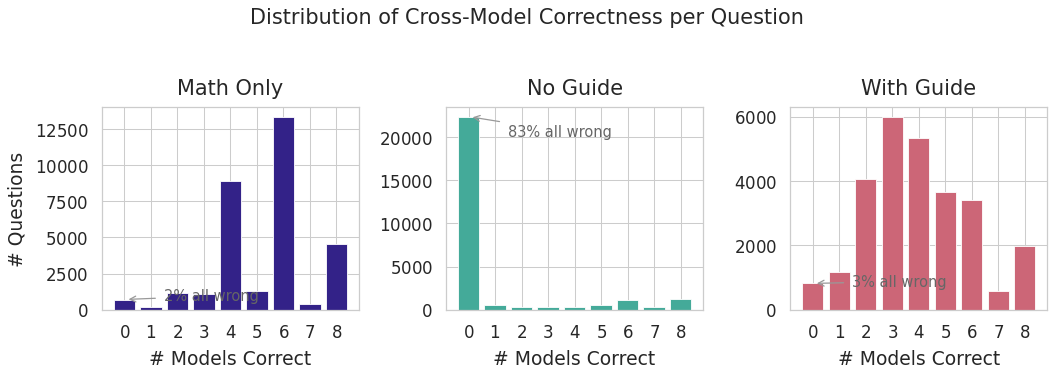

In [4]:
# ── 2. Distribution: how many models get each question right? ──

fig, axes = plt.subplots(1, 3, figsize=(PAGE_W, PAGE_W / GOLDEN / 1.8), sharey=False)

for ax, cond in zip(axes, COND_ORDER):
    subset = q_agg[q_agg['condition'] == cond]
    max_m = int(subset['n_models'].max())
    counts = subset['n_correct'].value_counts().reindex(range(max_m + 1), fill_value=0).sort_index()
    ax.bar(counts.index, counts.values, color=COND_COLORS[cond], edgecolor='white', linewidth=0.4)
    ax.set_xlabel('# Models Correct')
    ax.set_title(COND_LABELS[cond])
    ax.set_xticks(range(max_m + 1))

    zero_pct = (counts.get(0, 0) / counts.sum() * 100)
    all_pct = (counts.get(max_m, 0) / counts.sum() * 100)
    ax.annotate(f'{zero_pct:.0f}% all wrong', xy=(0, counts.get(0, 0)),
                xytext=(1.5, counts.get(0, 0) * 0.9), fontsize=7, color='#666',
                arrowprops=dict(arrowstyle='->', color='#999', lw=0.6))

axes[0].set_ylabel('# Questions')
fig.suptitle('Distribution of Cross-Model Correctness per Question', fontsize=10, y=1.03)
plt.tight_layout()
save_fig(fig, 'hardest_questions_distribution')
plt.show()

Total universally-wrong questions: 23,912
  (tested by ≥4 models, 0 got correct)

               Math Only  No Guide  With Guide  total
domain                                               
currency             701     22165         811  23677
timezone               0       135           0    135
clothing_size          0        87           3     90
bits_bytes             0        10           0     10
  → saved hardest_questions_by_domain.pdf / .png


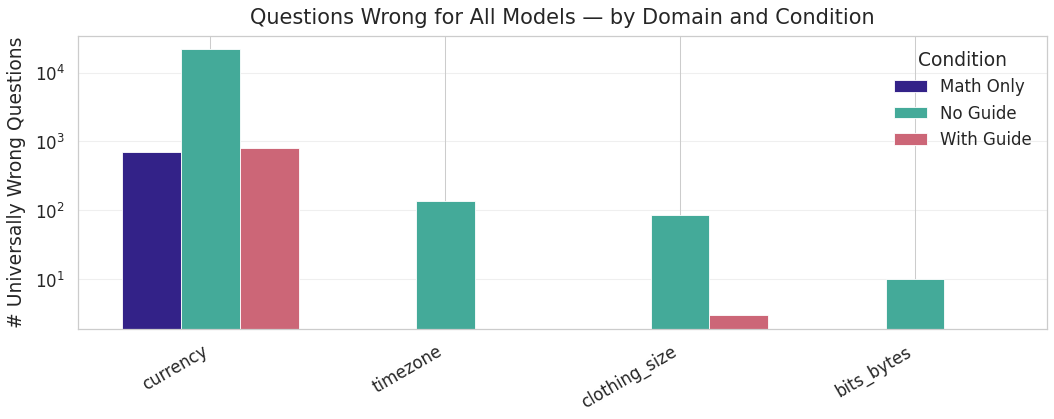

In [5]:
# ── 3. Universally wrong questions: breakdown by domain × condition ──

always_wrong = q_agg[q_agg['n_correct'] == 0].copy()

print(f'Total universally-wrong questions: {len(always_wrong):,}')
print(f'  (tested by \u22654 models, 0 got correct)\n')

cross = always_wrong.groupby(['domain', 'condition']).size().unstack('condition', fill_value=0)
cross = cross.reindex(columns=COND_ORDER, fill_value=0)
cross['total'] = cross.sum(axis=1)
cross = cross.sort_values('total', ascending=False)
cross.columns = [COND_LABELS.get(c, c) for c in cross.columns]
print(cross.to_string())

# Bar chart
plot_cross = always_wrong.groupby(['domain', 'condition']).size().reset_index(name='count')
fig, ax = plt.subplots(figsize=(PAGE_W, PAGE_W / GOLDEN / 1.5))

domains_sorted = cross.index.tolist()
x = np.arange(len(domains_sorted))
bw = 0.25

for j, cond in enumerate(COND_ORDER):
    vals = []
    for d in domains_sorted:
        row = plot_cross[(plot_cross['domain'] == d) & (plot_cross['condition'] == cond)]
        vals.append(row['count'].values[0] if len(row) else 0)
    offsets = x + (j - 1) * bw
    ax.bar(offsets, vals, bw, color=COND_COLORS[cond], edgecolor='white',
           linewidth=0.4, label=COND_LABELS[cond])

ax.set_xticks(x)
ax.set_xticklabels(domains_sorted, rotation=30, ha='right')
ax.set_ylabel('# Universally Wrong Questions')
ax.set_title('Questions Wrong for All Models — by Domain and Condition')
ax.set_yscale('log')
ax.legend(title='Condition')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
save_fig(fig, 'hardest_questions_by_domain')
plt.show()

  → saved hardest_questions_heatmap.pdf / .png


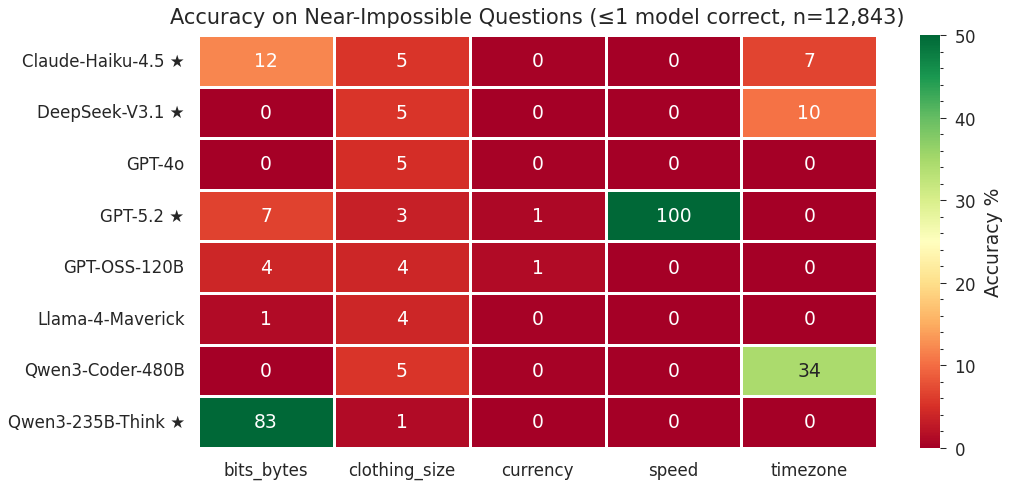

In [6]:
# ── 4. Per-model error rate on the universally-hard questions ──
# Restrict to the questions that \u22656 models attempted and \u22641 got right

near_impossible = q_agg[(q_agg['n_correct'] <= 1) & (q_agg['n_models'] >= 6)].copy()

# Join back to per-row data
hard_rows = df.merge(near_impossible[Q_KEYS], on=Q_KEYS, how='inner')

model_domain_acc = (
    hard_rows.groupby(['model', 'domain'])['is_correct']
    .mean().mul(100).unstack('domain').fillna(0)
)
model_domain_acc.index = model_domain_acc.index.map(lambda m: MODEL_DISPLAY.get(m, m))

fig, ax = plt.subplots(figsize=(PAGE_W, PAGE_W / GOLDEN / 1.3))
sns.heatmap(model_domain_acc, annot=True, fmt='.0f', cmap='RdYlGn', vmin=0, vmax=50,
            linewidths=0.5, linecolor='white', ax=ax, cbar_kws={'label': 'Accuracy %'})
ax.set_title(f'Accuracy on Near-Impossible Questions (\u22641 model correct, n={len(near_impossible):,})')
ax.set_ylabel('')
ax.set_xlabel('')
plt.tight_layout()
save_fig(fig, 'hardest_questions_heatmap')
plt.show()

In [7]:
# ── 5. Excluding currency (dominates the universally-wrong set) ──

non_currency = q_agg[q_agg['domain'] != 'currency'].copy()
non_curr_wrong = non_currency[non_currency['n_correct'] == 0]

print(f'Universally-wrong questions (excluding currency): {len(non_curr_wrong):,}\n')

cross_nc = non_curr_wrong.groupby(['domain', 'condition']).size().unstack('condition', fill_value=0)
cross_nc = cross_nc.reindex(columns=COND_ORDER, fill_value=0)
cross_nc['total'] = cross_nc.sum(axis=1)
cross_nc = cross_nc.sort_values('total', ascending=False)
cross_nc.columns = [COND_LABELS.get(c, c) for c in cross_nc.columns]
print(cross_nc.to_string())

print('\n--- Difficulty breakdown (non-currency universally wrong) ---')
print(non_curr_wrong['difficulty'].value_counts().to_string())

Universally-wrong questions (excluding currency): 235

               Math Only  No Guide  With Guide  total
domain                                               
timezone               0       135           0    135
clothing_size          0        87           3     90
bits_bytes             0        10           0     10

--- Difficulty breakdown (non-currency universally wrong) ---
difficulty
Easy    143
Hard     92


In [8]:
# ── 6. Examine specific universally-wrong questions (non-currency) ──

non_curr_wrong_keys = non_curr_wrong[Q_KEYS]
hard_examples = df.merge(non_curr_wrong_keys, on=Q_KEYS, how='inner')

for domain in non_curr_wrong['domain'].unique():
    dom_qs = non_curr_wrong[non_curr_wrong['domain'] == domain]
    print(f'\n{"=" * 70}')
    print(f'  {domain.upper()} — {len(dom_qs)} universally-wrong questions')
    print(f'{"=" * 70}')
    
    for _, q_row in dom_qs.head(5).iterrows():
        mask = (
            (hard_examples['domain'] == q_row['domain']) &
            (hard_examples['condition'] == q_row['condition']) &
            (hard_examples['number'].astype(str) == str(q_row['number'])) &
            (hard_examples['answer'].astype(str) == str(q_row['answer']))
        )
        rows = hard_examples[mask]
        print(f'\n  Q: number={q_row["number"]}, expected={q_row["answer"]}, condition={q_row["condition"]}')
        prompt_text = rows['prompt'].iloc[0] if len(rows) else 'N/A'
        print(f'  Prompt: {prompt_text[:200]}...' if len(prompt_text) > 200 else f'  Prompt: {prompt_text}')
        for _, r in rows.iterrows():
            status = '\u2713' if r['is_correct'] else '\u2717'
            print(f'    {status} {MODEL_DISPLAY.get(r["model"], r["model"]):25s}  '
                  f'answered={r["model_answer"]}  loss={r["loss"]}')


  BITS_BYTES — 10 universally-wrong questions

  Q: number=0.0921, expected=1.15125e-08, condition=in_domain_no_guide
  Prompt: Convert 0.0921 bits to megabytes. Provide only the numerical value.
    ✗ DeepSeek-V3.1 ★            answered=1.098e-08  loss=4.625407166123778
    ✗ GPT-4o                     answered=1.0925e-08  loss=5.103148751357216
    ✗ GPT-5.2 ★                  answered=1.0985136103630066e-08  loss=4.580793888121028
    ✗ Llama-4-Maverick           answered=0.0  loss=100.0
    ✗ Qwen3-Coder-480B           answered=0.0  loss=100.0
    ✗ Qwen3-235B-Think ★         answered=1.15e-08  loss=0.1085776330075942

  Q: number=1297.195, expected=0.000162149375, condition=in_domain_no_guide
  Prompt: Convert 1297.195 bits to megabytes. Provide only the numerical value.
    ✗ DeepSeek-V3.1 ★            answered=0.0001547  loss=4.594143517358606
    ✗ GPT-4o                     answered=0.0001543  loss=4.840829636253596
    ✗ GPT-5.2 ★                  answered=0.0001546369171142

difficulty  total_qs  all_wrong  pct_all_wrong  mean_pct_correct
      Easy     50854      11180           22.0        381.800895
      Hard     51141      12732           24.9        350.302352
  → saved hardest_questions_difficulty.pdf / .png


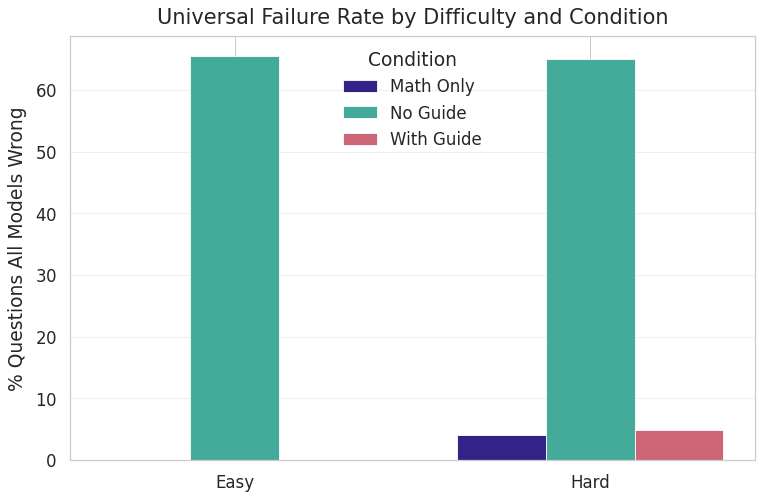

In [9]:
# ── 7. Are universally-wrong questions disproportionately "Hard"? ──

q_agg_with_diff = q_agg[q_agg['difficulty'].isin(['Easy', 'Hard'])].copy()

diff_stats = q_agg_with_diff.groupby('difficulty').agg(
    total_qs=('n_correct', 'count'),
    all_wrong=('n_correct', lambda x: (x == 0).sum()),
    all_correct=('n_correct', lambda x: (x == x.name).sum() if hasattr(x, 'name') else 0),
    mean_pct_correct=('pct_correct', 'mean'),
).reset_index()

diff_stats['pct_all_wrong'] = (diff_stats['all_wrong'] / diff_stats['total_qs'] * 100).round(1)
print(diff_stats[['difficulty', 'total_qs', 'all_wrong', 'pct_all_wrong', 'mean_pct_correct']].to_string(index=False))

# Grouped bar: fraction universally wrong by difficulty × condition
diff_cond = q_agg_with_diff.groupby(['difficulty', 'condition']).agg(
    total=('n_correct', 'count'),
    all_wrong=('n_correct', lambda x: (x == 0).sum()),
).reset_index()
diff_cond['pct_all_wrong'] = (diff_cond['all_wrong'] / diff_cond['total'] * 100)

fig, ax = plt.subplots(figsize=(COL_W * 1.5, COL_W))
x = np.arange(2)
bw = 0.25
for j, cond in enumerate(COND_ORDER):
    vals = []
    for diff in ['Easy', 'Hard']:
        row = diff_cond[(diff_cond['difficulty'] == diff) & (diff_cond['condition'] == cond)]
        vals.append(row['pct_all_wrong'].values[0] if len(row) else 0)
    ax.bar(x + (j - 1) * bw, vals, bw, color=COND_COLORS[cond], edgecolor='white',
           linewidth=0.4, label=COND_LABELS[cond])

ax.set_xticks(x)
ax.set_xticklabels(['Easy', 'Hard'])
ax.set_ylabel('% Questions All Models Wrong')
ax.set_title('Universal Failure Rate by Difficulty and Condition')
ax.legend(title='Condition')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
save_fig(fig, 'hardest_questions_difficulty')
plt.show()

  → saved hardest_questions_domain_spectrum.pdf / .png


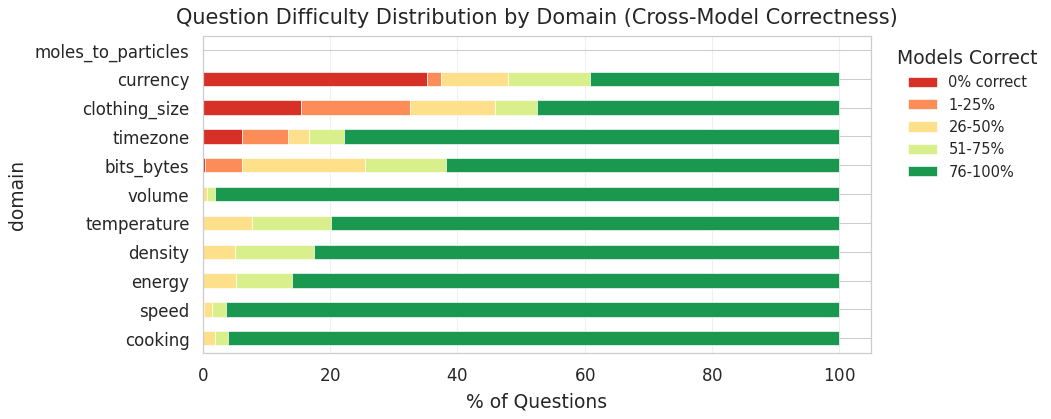

In [10]:
# ── 8. Most-often-wrong questions (gradient from always to mostly wrong) ──
# Fraction of questions by how many models got them wrong, per domain

q_agg['wrong_bucket'] = pd.cut(
    q_agg['pct_correct'],
    bins=[-1, 0, 25, 50, 75, 100],
    labels=['0% correct', '1-25%', '26-50%', '51-75%', '76-100%']
)

bucket_by_domain = (
    q_agg.groupby(['domain', 'wrong_bucket']).size()
    .unstack('wrong_bucket', fill_value=0)
)
bucket_pct = bucket_by_domain.div(bucket_by_domain.sum(axis=1), axis=0).mul(100)

# Sort by fraction of 0% correct
bucket_pct = bucket_pct.sort_values('0% correct', ascending=True)

fig, ax = plt.subplots(figsize=(PAGE_W, PAGE_W / GOLDEN / 1.5))
cmap = ['#d73027', '#fc8d59', '#fee08b', '#d9ef8b', '#1a9850']
bucket_pct.plot.barh(stacked=True, color=cmap, edgecolor='white', linewidth=0.3, ax=ax)
ax.set_xlabel('% of Questions')
ax.set_title('Question Difficulty Distribution by Domain (Cross-Model Correctness)')
ax.legend(title='Models Correct', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=7)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
save_fig(fig, 'hardest_questions_domain_spectrum')
plt.show()

  → saved hardest_questions_reasoning_rescue.pdf / .png


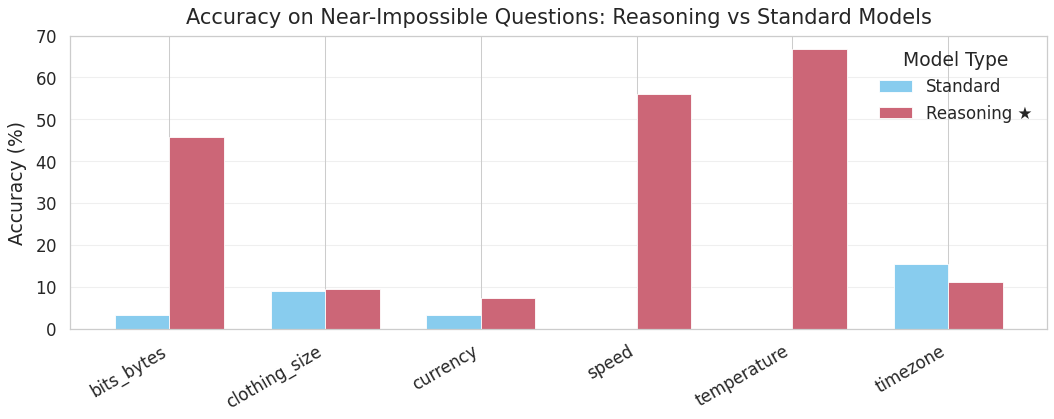


Overall accuracy on near-impossible questions:
              count  accuracy_%
is_reasoning                   
Standard      59223         3.5
Reasoning ★   34647         9.5


In [11]:
# ── 9. Do reasoning models rescue universally-hard questions? ──

mostly_wrong = q_agg[(q_agg['n_correct'] <= 2) & (q_agg['n_models'] >= 6)].copy()
mostly_wrong_rows = df.merge(mostly_wrong[Q_KEYS], on=Q_KEYS, how='inner')
mostly_wrong_rows['is_reasoning'] = mostly_wrong_rows['model'].isin(REASONING_MODELS)

reasoning_rescue = (
    mostly_wrong_rows.groupby(['is_reasoning', 'domain'])['is_correct']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'accuracy', 'count': 'n'})
    .reset_index()
)
reasoning_rescue['accuracy_%'] = (reasoning_rescue['accuracy'] * 100).round(1)
reasoning_rescue['type'] = reasoning_rescue['is_reasoning'].map({True: 'Reasoning \u2605', False: 'Standard'})

fig, ax = plt.subplots(figsize=(PAGE_W, PAGE_W / GOLDEN / 1.5))
domains_present = sorted(reasoning_rescue['domain'].unique())
x = np.arange(len(domains_present))
bw = 0.35

for j, (is_r, label, color) in enumerate([(False, 'Standard', '#88CCEE'), (True, 'Reasoning \u2605', '#CC6677')]):
    vals = []
    for d in domains_present:
        row = reasoning_rescue[(reasoning_rescue['domain'] == d) & (reasoning_rescue['is_reasoning'] == is_r)]
        vals.append(row['accuracy_%'].values[0] if len(row) else 0)
    ax.bar(x + (j - 0.5) * bw, vals, bw, color=color, edgecolor='white', linewidth=0.4, label=label)

ax.set_xticks(x)
ax.set_xticklabels(domains_present, rotation=30, ha='right')
ax.set_ylabel('Accuracy (%)')
ax.set_title('Accuracy on Near-Impossible Questions: Reasoning vs Standard Models')
ax.legend(title='Model Type')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
save_fig(fig, 'hardest_questions_reasoning_rescue')
plt.show()

# Overall summary
overall = mostly_wrong_rows.groupby('is_reasoning')['is_correct'].agg(['mean', 'count'])
overall.index = overall.index.map({True: 'Reasoning \u2605', False: 'Standard'})
overall['accuracy_%'] = (overall['mean'] * 100).round(1)
print('\nOverall accuracy on near-impossible questions:')
print(overall[['count', 'accuracy_%']].to_string())

In [12]:
# ── 10. Currency deep-dive (largest source of universal failure) ──

curr = q_agg[q_agg['domain'] == 'currency'].copy()
print(f'Currency questions: {len(curr):,}')
print(f'  All models wrong: {(curr["n_correct"] == 0).sum():,} ({(curr["n_correct"] == 0).mean()*100:.1f}%)')
print(f'  All models right: {(curr["n_correct"] == curr["n_models"]).sum():,} ({(curr["n_correct"] == curr["n_models"]).mean()*100:.1f}%)')

# By condition
curr_cond = curr.groupby('condition').agg(
    total=('n_correct', 'count'),
    all_wrong=('n_correct', lambda x: (x == 0).sum()),
    mean_pct=('pct_correct', 'mean'),
).reset_index()
curr_cond['pct_all_wrong'] = (curr_cond['all_wrong'] / curr_cond['total'] * 100).round(1)
curr_cond['condition'] = curr_cond['condition'].map(COND_LABELS)
print('\nCurrency by condition:')
print(curr_cond.to_string(index=False))

# Examine: what does a wrong currency answer look like?
curr_wrong_keys = curr[curr['n_correct'] == 0][Q_KEYS].head(3)
curr_examples = df.merge(curr_wrong_keys, on=Q_KEYS, how='inner')

print('\n--- Sample universally-wrong currency questions ---')
for (_, num, ans), grp in curr_examples.groupby(['domain', 'number', 'answer']):
    print(f'\n  number={num}, expected={ans}')
    prompt_text = grp['prompt'].iloc[0]
    print(f'  Prompt: {prompt_text[:250]}...' if len(prompt_text) > 250 else f'  Prompt: {prompt_text}')
    for _, r in grp.iterrows():
        print(f'    {MODEL_DISPLAY.get(r["model"], r["model"]):25s}  answered={r["model_answer"]}  loss={r["loss"]}')

Currency questions: 67,200
  All models wrong: 23,677 (35.2%)
  All models right: 22,589 (33.6%)

Currency by condition:
 condition  total  all_wrong  mean_pct  pct_all_wrong
  No Guide  22400      22165  0.213192           99.0
With Guide  22400        811 66.013982            3.6
 Math Only  22400        701 91.962121            3.1

--- Sample universally-wrong currency questions ---

  number=0.0019, expected=0.0001366255026426
  Prompt: Convert 0.0019 IRR to LBP. Provide only the numerical value.
    GPT-4o                     answered=0.0007  loss=412.3494416932811
    GPT-5.2 ★                  answered=0.0040488  loss=2863.429170753938
    Llama-4-Maverick           answered=0.004  loss=2827.711095390177
    Qwen3-Coder-480B           answered=0.0001  loss=26.80722261524556

  number=0.0019, expected=0.0001943530099357
  Prompt: Convert 0.0019 LBP to GNF. Provide only the numerical value.
    GPT-4o                     answered=0.0114  loss=5765.615358245078
    GPT-5.2 ★      

In [13]:
# ── 11. Summary statistics ──

print('=' * 60)
print('  SUMMARY: Universally & Most-Often Wrong Questions')
print('=' * 60)
print(f'\nTotal questions analysed (\u22654 models): {len(q_agg):,}')
print(f'Universally wrong (0 models correct):  {(q_agg["n_correct"] == 0).sum():,} ({(q_agg["n_correct"] == 0).mean()*100:.1f}%)')
print(f'  of which currency:                   {len(always_wrong[always_wrong["domain"] == "currency"]):,}')
print(f'  of which non-currency:               {len(non_curr_wrong):,}')
print(f'Mostly wrong (\u22641 model correct):       {(q_agg["n_correct"] <= 1).sum():,} ({(q_agg["n_correct"] <= 1).mean()*100:.1f}%)')
print(f'Always correct (all models right):     {(q_agg["n_correct"] == q_agg["n_models"]).sum():,} ({(q_agg["n_correct"] == q_agg["n_models"]).mean()*100:.1f}%)')
print(f'\nKey findings:')
print(f'  1. Currency dominates universal failures ({(len(always_wrong[always_wrong["domain"] == "currency"]) / len(always_wrong) * 100):.0f}% of all universally-wrong Qs)')
print(f'  2. No-guide condition is hardest ({(always_wrong["condition"] == "in_domain_no_guide").mean()*100:.0f}% of universally-wrong Qs)')
print(f'  3. Non-currency domains with universal failures: {sorted(non_curr_wrong["domain"].unique())}')

  SUMMARY: Universally & Most-Often Wrong Questions

Total questions analysed (≥4 models): 101,995
Universally wrong (0 models correct):  23,912 (23.4%)
  of which currency:                   23,677
  of which non-currency:               235
Mostly wrong (≤1 model correct):       25,744 (25.2%)
Always correct (all models right):     35,134 (34.4%)

Key findings:
  1. Currency dominates universal failures (99% of all universally-wrong Qs)
  2. No-guide condition is hardest (94% of universally-wrong Qs)
  3. Non-currency domains with universal failures: ['bits_bytes', 'clothing_size', 'timezone']
